# L9 — Unsupervised Learning on Text: Recovering Cuisines from Ingredients

**STA272 · Week 9 · 26 Mar 2026**

Last week we clustered recipes by their *nutritional features* (calories, fat, carbs, protein) and found that k-means could partially recover cuisine groupings. Today we ask a different question:

> **Can we recover cuisine structure from ingredient text alone — no nutrition data, no labels?**

We'll explore three ways to turn text into numbers:

| Representation | Type | Key idea |
|---|---|---|
| TF-IDF | Sparse, data-driven | Weight words by how distinctive they are |
| GloVe embeddings | Dense, pre-trained | Words with similar meaning have similar vectors |
| Autoencoder bottleneck | Dense, learned | Compress TF-IDF end-to-end for this dataset |

For each representation we'll cluster with k-means (which you already know from Week 8) and compare how well the clusters align with the true cuisine labels. We'll also build a **recipe search engine** — given a list of ingredients, find the most similar recipes using cosine similarity on each of the three representations.

**Data source:** [TidyTuesday 2025-09-16 — Recipes & Cuisines](https://github.com/rfordatascience/tidytuesday/blob/main/data/2025/2025-09-16/readme.md)

## Learning Outcomes

By the end of this lecture, you will be able to:

1. **Explain TF-IDF** — describe how term frequency and inverse document frequency work together to weight words by distinctiveness, and compute TF-IDF values by hand for a small example.

2. **Define cosine similarity** — explain why it is preferred over Euclidean distance for sparse text data.

3. **Define what an embedding is** — explain the idea of mapping discrete objects (words, recipes) to dense numerical vectors, distinguish between pre-trained and learned embeddings.

4. **Use GloVe word embeddings** — load pre-trained vectors, explain the distributional hypothesis ("words in similar contexts have similar meanings"), and aggregate word vectors into a document-level representation by averaging.

5. **Build and interpret a shallow autoencoder** — describe the encoder–bottleneck–decoder architecture, train one in Keras using the build-compile-fit pattern, and extract bottleneck activations as a learned embedding.

6. **Compare text representations for clustering** — apply k-means to TF-IDF, GloVe, and autoencoder representations, evaluate cluster quality using silhouette score and cluster purity.

7. **Build a similarity-based search engine** — use cosine similarity on any of the three representations to retrieve the most similar recipes given a free-text ingredient query.

---
## 0 · Setup & Data Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
all_recipes = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/all_recipes.csv'
)
cuisines = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/cuisines.csv'
)

print(f"all_recipes : {all_recipes.shape[0]:,} recipes × {all_recipes.shape[1]} columns")
print(f"cuisines    : {cuisines.shape[0]:,} recipes × {cuisines.shape[1]} columns")

all_recipes : 14,426 recipes × 16 columns
cuisines    : 2,218 recipes × 17 columns


In [3]:
# The cuisines table is a subset of all_recipes with an extra 'country' column.
# Merge on 'url' (unique per recipe) to attach cuisine labels.
recipes_df = all_recipes.merge(cuisines[['url', 'country']], on='url', how='inner')

# Drop recipes with missing ingredients
recipes_df = recipes_df.dropna(subset=['ingredients']).reset_index(drop=True)

print(f"Merged dataset: {recipes_df.shape[0]:,} recipes × {recipes_df.shape[1]} columns")
print(f"\nColumn dtypes:")
print(recipes_df.dtypes)
print(f"\n--- Sample ingredient lists ---")
for i in [0, 100, 500]:
    print(f"\n[{recipes_df.loc[i, 'name']}]  ({recipes_df.loc[i, 'country']})")
    print(recipes_df.loc[i, 'ingredients'][:120], "...")

Merged dataset: 1,055 recipes × 17 columns

Column dtypes:
name                  str
url                   str
author                str
date_published        str
ingredients           str
calories          float64
fat               float64
carbs             float64
protein           float64
avg_rating        float64
total_ratings     float64
reviews           float64
prep_time           int64
cook_time           int64
total_time          int64
servings          float64
country               str
dtype: object

--- Sample ingredient lists ---

[Quince Empanadas]  (Argentinian)
6 tablespoons warm water, 1 teaspoon salt, 2 cups all-purpose flour, sifted, ¼ cup unsalted butter, melted, 1 large egg, ...

[Jalapeño Jelly]  (Canadian)
1 large green bell pepper, 12 jalapeño peppers, 1 ½ cups apple cider vinegar, 1 pinch salt, 4 ¼ cups granulated sugar, 4 ...

[Slow Cooker Tuscan Chicken Meatballs with Gnocchi]  (Italian)
1 large egg, 1/4 cup fine dry bread crumbs, 1/4 cup finely chopped onion,

Number of cuisines: 47



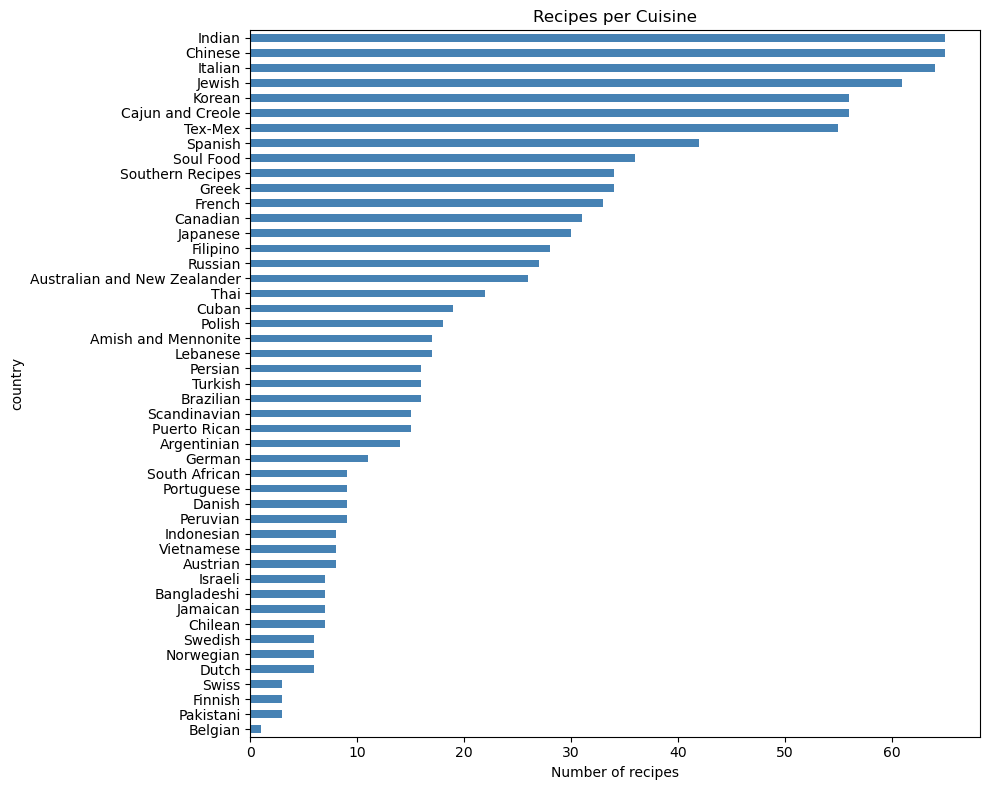

In [4]:
print(f"Number of cuisines: {recipes_df['country'].nunique()}\n")

cuisine_counts = recipes_df['country'].value_counts()
fig, ax = plt.subplots(figsize=(10, 8))
cuisine_counts.plot.barh(ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Number of recipes')
ax.set_title('Recipes per Cuisine')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

From here on we will treat the `country` column as **hidden ground truth**. We won't use it in any model — only to evaluate our clusters at the end of each section.

### 0.1 Text as data

So far in this course, almost every dataset has been a table of numbers — calories, protein, ratings. But the `ingredients` column is **text**: a comma-separated list of ingredient phrases. Before we can cluster recipes by their ingredients, we need to convert this text into numbers.

The simplest idea: **count how often each word appears** in a recipe's ingredient list. This gives us a numeric vector for every recipe — one entry per unique word in the entire corpus.

**Problem:** some words appear in almost every recipe ("salt", "cup", "tablespoon") but tell us nothing about what cuisine the recipe belongs to. These common, uninformative words are called **stop words**. In natural language processing, stop words like "the", "and", "of" are routinely removed. In recipe data, measurement words ("tablespoon", "cup", "ounce") play a similar role — they're everywhere but carry no cuisine signal.

Let's look at one recipe to see this in action.

In [5]:
# Pick one Indian recipe to examine
sample = recipes_df[recipes_df['country'] == 'Indian'].iloc[0]
print(f"Recipe: {sample['name']}")
print(f"Cuisine: {sample['country']}")
print(f"\nRaw ingredients:\n{sample['ingredients']}")

Recipe: Authentic Saag Paneer
Cuisine: Indian

Raw ingredients:
2 bunches spinach, roughly chopped, 1 bunch fenugreek leaves, roughly chopped, 3 tablespoons canola oil, divided, ½ pound paneer, cubed, 1 teaspoon cumin seeds, 1  onion, thinly sliced, 3 cloves garlic, minced, 1 teaspoon grated fresh ginger, 1  tomato, diced, 2 teaspoons garam masala, ½ teaspoon ground turmeric, ½ teaspoon cayenne pepper, ½ cup heavy whipping cream, salt to taste


**Tokenising:** we split the ingredient string into individual words (lowercase, letters only). Then we count how often each word appears using `pandas.Series.value_counts()`.

In [6]:
# make sure words are lower case, remove commas, then split

words = sample['ingredients'].lower().replace(',', '').split()

# Count word frequencies using pandas
freq_df = (pd.Series(words)
             .value_counts()
             .reset_index()
             .rename(columns={'index': 'word', 'count': 'count'}))

print(f"Total words: {len(words)}  |  Unique words: {freq_df.shape[0]}\n")
freq_df.head(8)

Total words: 60  |  Unique words: 46



,word,count
0,1,5
1,½,4
2,teaspoon,4
3,2,2
4,roughly,2
5,chopped,2
6,3,2
7,bunches,1


The most frequent words are things like "teaspoon", "roughly", "chopped" — **stop words** that can appear in recipes regardless of cuisine. Let's plot the raw counts to see this clearly.

### 0.2 Stop words

- Let's remove the **stop words** — common English words and measurement terms — and see what's left.
- The words that are left tell us something about the *cuisine*.
- By inspection of a few recipes a few common stop words are: tablespoon, tablespoons, teaspoon, and teaspoons.
- Create a set (a Python data structure):

 ```
 stop_words = {'and', 'or', 'of', 'to', 'a', 'the', 'as', 'in', 'for', 'with',
              'cup', 'cups', 'tablespoon', 'tablespoons', 'teaspoon', 'teaspoons',
              'ounce', 'ounces', 'pound', 'pounds', 'inch', 'needed'}
```

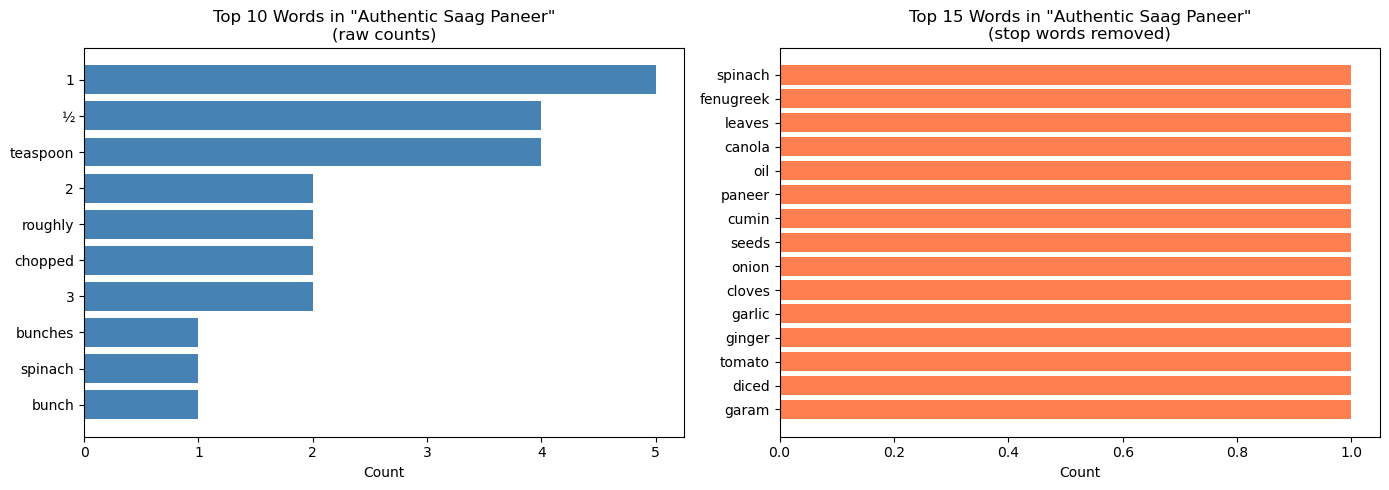

Now we see actual ingredients — cumin, turmeric, ginger — that signal 'Indian cuisine'.
TF-IDF automates this idea: it down-weights common words and up-weights distinctive ones.
Stop words are not well defined.  Should fresh be a stop word?


In [7]:
# Define stop words: common English words + measurement terms
stop_words = {'and', 'or', 'of', 'to', 'a', 'the', 'as', 'in', 'for', 'with',
              'cup', 'cups', 'tablespoon', 'tablespoons', 'teaspoon', 'teaspoons',
              'ounce', 'ounces', 'pound', 'pounds', 'inch', 'needed', 'roughly', 'divided', 
              'chopped', 'bunches', 'cubed', 'thinly', 'sliced', 'minced', 'grated', 'bunch',
             'taste', 'extract', 'shredded', 'powder', 'purpose', 'active', 'fresh',
             'seasoning', 'package', 'white'}

# Filter: remove stop words and very short words (≤ 2 letters)
filt_df = freq_df[~freq_df['word'].isin(stop_words) & (freq_df['word'].str.len() > 2)].head(15)

# Side-by-side comparison: raw counts vs stop words removed
top15 = freq_df.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw word counts
ax1.barh(top15['word'][::-1], top15['count'][::-1], color='steelblue')
ax1.set_title(f'Top 10 Words in "{sample["name"]}"\n(raw counts)')
ax1.set_xlabel('Count')

# Right: after removing stop words
ax2.barh(filt_df['word'][::-1], filt_df['count'][::-1], color='coral')
ax2.set_title(f'Top 15 Words in "{sample["name"]}"\n(stop words removed)')
ax2.set_xlabel('Count')

plt.tight_layout()
plt.show()

print("Now we see actual ingredients — cumin, turmeric, ginger — that signal 'Indian cuisine'.")
print("TF-IDF automates this idea: it down-weights common words and up-weights distinctive ones.")
print("Stop words are not well defined.  Should fresh be a stop word?")

---
## 1 · From Text to Numbers: TF-IDF

### 1.1 Intuition: why not just count words?

Imagine we have three short recipes:

| Recipe | Ingredients |
|---|---|
| A | salt, cumin, chickpeas |
| B | salt, soy sauce, ginger |
| C | salt, cumin, coriander |

Every recipe contains "salt", so counting it doesn't help distinguish cuisines. "Cumin" appears in A and C but not B — it's more informative.

**TF-IDF** (Term Frequency – Inverse Document Frequency) formalises this intuition:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

where

- $\text{TF}(t, d)$ = how often term $t$ appears in document $d$ (here, a recipe's ingredient list)
- $\text{IDF}(t) = \log\!\left(\dfrac{1 + N}{1 + \text{DF}(t)}\right) + 1$, with $N$ = total documents and $\text{DF}(t)$ = number of documents containing $t$

The "+1" terms are **smoothing** — they prevent division by zero and ensure that even a term appearing in every document still gets a small positive weight. After computing the raw TF-IDF values, each document's vector is **L2-normalised** (divided by its Euclidean length) so that long and short ingredient lists are on the same scale.

Words that appear in nearly every recipe (like "salt") get a **low IDF** → low TF-IDF weight.  
Words that appear in only a few recipes (like "chickpeas") get a **high IDF** → high TF-IDF weight.

In [8]:
# Toy example: three mini-recipes
docs = ['salt cumin chickpeas', 'salt soy ginger', 'salt cumin coriander']
recipe_labels = ['A', 'B', 'C']
all_terms = sorted({w for d in docs for w in d.split()})
N = len(docs)  # 3

import math

# Step 1: compute TF and IDF (sklearn's smoothed formula)
rows = []
for t in all_terms:
    df_t = sum(1 for d in docs if t in d.split())
    idf = math.log((1 + N) / (1 + df_t)) + 1
    row = {'term': t, 'DF': df_t, 'IDF': round(idf, 4)}
    for label, d in zip(recipe_labels, docs):
        tf = d.split().count(t)
        row[f'raw ({label})'] = round(tf * idf, 4)
    rows.append(row)

raw_df = pd.DataFrame(rows).set_index('term')

# Step 2: L2-normalise each recipe column (just like sklearn)
for label in recipe_labels:
    col = f'raw ({label})'
    norm = math.sqrt(sum(raw_df[col] ** 2))
    raw_df[f'TF-IDF ({label})'] = (raw_df[col] / norm).round(3)

raw_df[['DF', 'IDF'] + [f'TF-IDF ({label})' for label in recipe_labels]]

,DF,IDF,TF-IDF (A),TF-IDF (B),TF-IDF (C)
term,,,,,
chickpeas,1,1.6931,0.720,0.000,0.000
coriander,1,1.6931,0.000,0.000,0.720
cumin,2,1.2877,0.548,0.000,0.548
ginger,1,1.6931,0.000,0.652,0.000
salt,3,1.0000,0.425,0.385,0.425
soy,1,1.6931,0.000,0.652,0.000


### 1.2 The document-term matrix (toy version)

The table above shows TF-IDF weights per term. We can rearrange this into a **document-term matrix** — one row per recipe, one column per term. Each cell holds the TF-IDF weight of that term in that recipe. This is the format that clustering algorithms like k-means expect: each recipe is a **row vector** of numbers.

In [9]:
# Document-term matrix: rows = recipes, columns = terms
recipe_labels = ['A', 'B', 'C']
# .T is the transpose of the data frame turning rows to columns
toy_dtm = raw_df[[f'TF-IDF ({label})' for label in recipe_labels]].T
toy_dtm.index = ['Recipe A', 'Recipe B', 'Recipe C']
toy_dtm

term,chickpeas,coriander,cumin,ginger,salt,soy
Recipe A,0.72,0.00,0.548,0.000,0.425,0.000
Recipe B,0.00,0.00,0.000,0.652,0.385,0.652
Recipe C,0.00,0.72,0.548,0.000,0.425,0.000


### 1.3 What is `TfidfVectorizer`?

We just computed TF-IDF by hand. In practice we use sklearn's `TfidfVectorizer` — a tool that does three things in sequence:

1. **Learns the vocabulary** — scans every recipe and builds a list of all unique words (terms).
2. **Counts and weights** — for each recipe, counts how often each term appears, then applies the TF-IDF formula.
3. **Returns a matrix** — one row per recipe, one column per term, with the TF-IDF weight in each cell.

The two key methods are:
- `.fit_transform(texts)` — learns the vocabulary *and* computes a **sparse** matrix in one step.
- `.transform(new_texts)` — uses the *already-learned* vocabulary to convert new text (we'll use this later for the search engine) and computes a **sparse** matrix.

### 1.4 Why a "sparse" matrix?

Our toy example had 3 recipes and 6 terms — a small table we can print. But the real dataset will have ~2,000 recipes and ~2,000 terms, giving a table with **4 million cells**. Most of those cells are **zero** — any single recipe uses only a handful of the 2,000 possible terms.

A **sparse matrix** is a memory-saving trick: instead of storing all 4 million values (mostly zeros), it only stores the non-zero entries and their positions. Think of it like a guest list that only records who *showed up* to a party, rather than listing every person in the city and writing "absent" next to most of them.

The data is identical — you can always convert a sparse matrix back to a regular table with `.toarray()` — but sparse storage lets us work with large text datasets without running out of memory.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

toy_vectorizer = TfidfVectorizer()
toy_tfidf = toy_vectorizer.fit_transform(docs)

toy_sklearn = pd.DataFrame(
    toy_tfidf.toarray().round(3),
    index=['Recipe A', 'Recipe B', 'Recipe C'],
    columns=toy_vectorizer.get_feature_names_out()
)
toy_sklearn

,chickpeas,coriander,cumin,ginger,salt,soy
Recipe A,0.72,0.00,0.548,0.000,0.425,0.000
Recipe B,0.00,0.00,0.000,0.652,0.385,0.652
Recipe C,0.00,0.72,0.548,0.000,0.425,0.000


### 1.5 Building the document-term matrix

- When we apply TF-IDF to all recipes at once, the result is a **document-term matrix**: one row per recipe, one column per unique word (term), each entry is that term's TF-IDF weight in that recipe. 

- The matrix is *sparse* — most entries are zero because any single recipe uses only a small fraction of all possible words.

- We'll use `TfidfVectorizer` from sklearn to build this matrix.

In [11]:
# sklearn has a built-in list of common English stop words (the, and, of, ...).
# We combine it with our recipe-specific stop words (cup, tablespoon, ounce, ...)
# so that TfidfVectorizer ignores both kinds of uninformative words.

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
recipe_stop_words = list(ENGLISH_STOP_WORDS.union(stop_words))

# token_pattern: only keep tokens that are purely alphabetic (2+ letters),
# which excludes numbers like "1", "16", "350" from the vocabulary.

vectorizer = TfidfVectorizer(stop_words=recipe_stop_words, max_features=2000,
                             token_pattern=r'[a-zA-Z]{2,}')
tfidf_matrix = vectorizer.fit_transform(recipes_df['ingredients'])
feature_names = vectorizer.get_feature_names_out()

rows, cols = tfidf_matrix.shape
print(f"Document-term matrix: {rows:,} recipes × {cols:,} terms")
print(f"Non-zero entries: {tfidf_matrix.nnz:,}  ({100 * tfidf_matrix.nnz / (rows * cols):.1f}% dense)")

Document-term matrix: 1,055 recipes × 1,472 terms
Non-zero entries: 23,638  (1.5% dense)


In [12]:
# Show top 3 TF-IDF terms for a few recipes (same idea as the toy DataFrame)
sample_idx = [0, 100, 500]
sample_tfidf = pd.DataFrame(
    tfidf_matrix[sample_idx].toarray().round(3),
    #  recipes_df.loc[i, 'name'][:35] — gets the recipe name, truncated to 35 characters so long names don't break the table
    #  and appends the cuisine in parentheses
    index=[f"{recipes_df.loc[i, 'name'][:35]}  ({recipes_df.loc[i, 'country']})" for i in sample_idx],
    columns=feature_names
)

# Keep only the 3 highest-weight terms per recipe
top_cols = set()
for row in sample_tfidf.index:
    top_cols.update(sample_tfidf.loc[row].nlargest(3).index)

sample_tfidf[sorted(top_cols)]

,beaten,freshly,italian,jalape,membrillo,parmesan,pectin,peppers,quince
Quince Empanadas (Argentinian),0.352,0.000,0.000,0.000,0.364,0.000,0.000,0.000,0.364
Jalapeño Jelly (Canadian),0.000,0.000,0.000,0.535,0.000,0.000,0.355,0.368,0.000
Slow Cooker Tuscan Chicken Meatball (Italian),0.000,0.308,0.289,0.000,0.000,0.289,0.000,0.000,0.000


### 1.6 Visualising TF-IDF vectors

Each recipe is now a vector of TF-IDF weights — one per term in the vocabulary. Let's pick a few recipes from different cuisines and plot their top terms side by side. Recipes from the **same** cuisine should light up similar terms; recipes from **different** cuisines should look quite different. This is exactly the structure that k-means will try to find in the next section.

- We use `sns.heatmap()` from **seaborn** to display the TF-IDF weights as a colour-coded grid — rows are recipes and columns are terms. Higher weights appear in warmer colours, making it easy to spot which terms are distinctive for each cuisine.

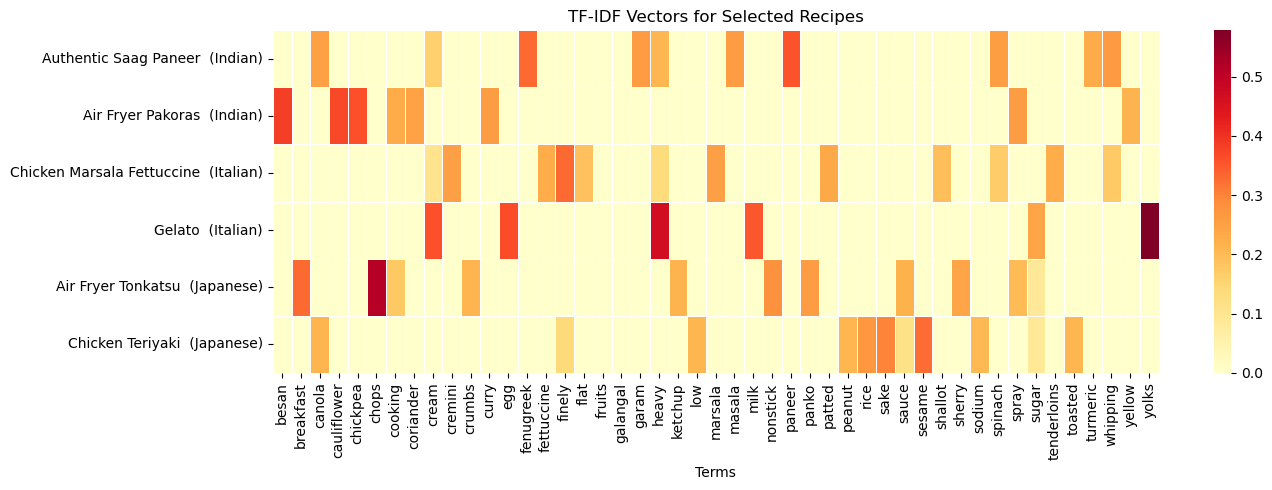

In [13]:
# Pick two recipes from each of three cuisines
sample_cuisines = ['Indian', 'Italian', 'Japanese']
sample_rows = []
for cuisine in sample_cuisines:
    idx = recipes_df[recipes_df['country'] == cuisine].index[:2]
    sample_rows.extend(idx)

# Collect the union of top-8 terms across all sampled recipes
top_n = 8
term_set = set()
for i in sample_rows:
    row = tfidf_matrix[i].toarray().flatten()
    term_set.update(row.argsort()[::-1][:top_n])

term_set = sorted(term_set, key=lambda j: feature_names[j])

# Build a small matrix: rows = sampled recipes, cols = union of top terms
plot_data = pd.DataFrame(
    tfidf_matrix[sample_rows][:, term_set].toarray(),
    index=[f"{recipes_df.loc[i, 'name'][:30]}  ({recipes_df.loc[i, 'country']})" for i in sample_rows],
    columns=[feature_names[j] for j in term_set]
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(plot_data, cmap='YlOrRd', linewidths=0.5, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('TF-IDF Vectors for Selected Recipes')
ax.set_xlabel('Terms')
plt.tight_layout()
plt.show()

---
## 2 · TF-IDF + K-Means Clustering

You already know k-means from Week 8. The algorithm is the same — the only difference is that our feature matrix is now a sparse TF-IDF matrix instead of the dense nutritional features we used last week.

**How does distance work here?** Each recipe is now a vector of TF-IDF weights — one number per term. Two recipes that use similar distinctive ingredients will have similar TF-IDF vectors, so the distance between them is **small**. Two recipes with very different ingredient profiles will have very different weights across those dimensions, so the distance between them is **large**. K-means exploits this: it groups recipes whose TF-IDF vectors are close together, which means recipes that share the same distinctive ingredients end up in the same cluster.

### 2.1 Cosine similarity

In Week 8, k-means used **Euclidean distance** — the straight-line distance between two points. That works well when features are on similar scales (e.g., calories and protein). But for sparse, high-dimensional text vectors, Euclidean distance has a problem: most entries are zero, so two recipes can look "far apart" simply because they have *different* zeros, even if the non-zero terms overlap a lot.

**Cosine similarity** fixes this by measuring the *angle* between two vectors rather than the distance between their endpoints:

$$\text{cosine\_similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \; \|\mathbf{b}\|}$$

where $\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i$ is the dot product and $\|\mathbf{a}\| = \sqrt{\sum_i a_i^2}$ is the vector length.

**Interpretation:**

| Cosine similarity | Meaning |
|---|---|
| **1** | Vectors point in exactly the same direction (identical ingredient profiles) |
| ~0.7-0.9| Very similar documents, heavy topic overlap |
| **0** | Vectors are perpendicular (no shared ingredients) |
| **< 0** | Vectors point in opposite directions (not possible for TF-IDF, since weights are ≥ 0) |

**Why it works for text:** cosine similarity only cares about *which* terms have high weights, not about the total magnitude of the vector. A short ingredient list and a long one can still have cosine similarity = 1 if they mention the same distinctive ingredients in the same proportions.

**A useful fact:** when vectors are already L2-normalised (length = 1), as `TfidfVectorizer` does by default, minimising Euclidean distance is mathematically equivalent to maximising cosine similarity. So sklearn's k-means — which uses Euclidean distance — is effectively doing cosine-based clustering on our TF-IDF data.

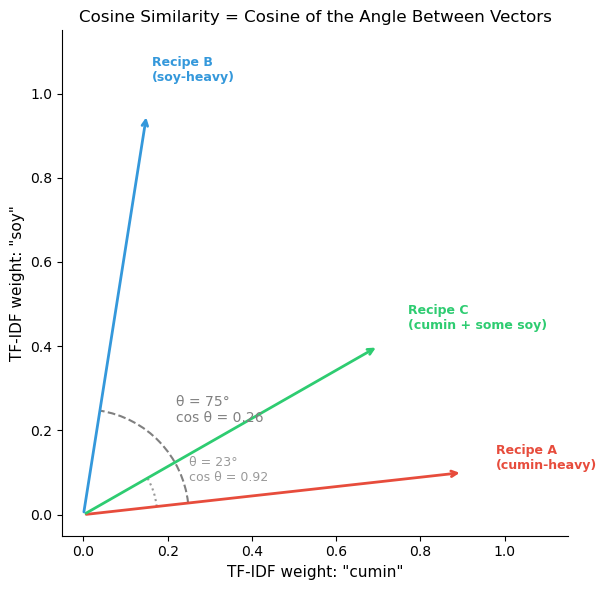

A ↔ C: small angle (23°), high similarity (0.92) — both use cumin
A ↔ B: large angle (75°), low similarity  (0.26) — different profiles


In [14]:
# Geometric view: cosine similarity = cosine of the angle between two vectors
# We'll use a simple 2D example with two ingredient axes: "cumin" and "soy"

import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7, 6))

# Three recipe vectors in 2D (cumin, soy)
vectors = {
    'Recipe A\n(cumin-heavy)':  np.array([0.9, 0.1]),
    'Recipe C\n(cumin + some soy)': np.array([0.7, 0.4]),
    'Recipe B\n(soy-heavy)':   np.array([0.15, 0.95]),
}
colours = ['#e74c3c', '#2ecc71', '#3498db']

for (label, vec), colour in zip(vectors.items(), colours):
    ax.annotate('', xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', lw=2, color=colour))
    # Place label at the tip of the arrow
    offset = vec / np.linalg.norm(vec) * 0.08
    ax.text(vec[0] + offset[0], vec[1] + offset[1], label,
            fontsize=9, fontweight='bold', color=colour, ha='left')

# Draw the angle arc between Recipe A and Recipe B
from matplotlib.patches import Arc
v_a = vectors['Recipe A\n(cumin-heavy)']
v_b = vectors['Recipe B\n(soy-heavy)']
angle_a = np.degrees(np.arctan2(v_a[1], v_a[0]))
angle_b = np.degrees(np.arctan2(v_b[1], v_b[0]))
arc = Arc((0, 0), 0.5, 0.5, angle=0, theta1=angle_a, theta2=angle_b,
          color='grey', lw=1.5, linestyle='--')
ax.add_patch(arc)

# Compute and label the angle
cos_ab = np.dot(v_a, v_b) / (np.linalg.norm(v_a) * np.linalg.norm(v_b))
theta_ab = np.degrees(np.arccos(cos_ab))
ax.text(0.22, 0.22, f'θ = {theta_ab:.0f}°\ncos θ = {cos_ab:.2f}',
        fontsize=10, color='grey', ha='left')

# Also show angle between A and C (small angle = high similarity)
v_c = vectors['Recipe C\n(cumin + some soy)']
cos_ac = np.dot(v_a, v_c) / (np.linalg.norm(v_a) * np.linalg.norm(v_c))
theta_ac = np.degrees(np.arccos(cos_ac))
angle_c = np.degrees(np.arctan2(v_c[1], v_c[0]))
arc2 = Arc((0, 0), 0.35, 0.35, angle=0, theta1=angle_a, theta2=angle_c,
           color='#999999', lw=1.5, linestyle=':')
ax.add_patch(arc2)
ax.text(0.25, 0.08, f'θ = {theta_ac:.0f}°\ncos θ = {cos_ac:.2f}',
        fontsize=9, color='#999999', ha='left')

ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.05, 1.15)
ax.set_xlabel('TF-IDF weight: "cumin"', fontsize=11)
ax.set_ylabel('TF-IDF weight: "soy"', fontsize=11)
ax.set_title('Cosine Similarity = Cosine of the Angle Between Vectors', fontsize=12)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"A ↔ C: small angle ({theta_ac:.0f}°), high similarity ({cos_ac:.2f}) — both use cumin")
print(f"A ↔ B: large angle ({theta_ab:.0f}°), low similarity  ({cos_ab:.2f}) — different profiles")




In [15]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Cosine similarity between our three toy recipes from Section 1
toy_sim = pd.DataFrame(
    cos_sim(toy_tfidf).round(3),
    index=['Recipe A', 'Recipe B', 'Recipe C'],
    columns=['Recipe A', 'Recipe B', 'Recipe C']
)
print("Cosine similarity between toy recipes:")
print("(A = salt/cumin/chickpeas, B = salt/soy/ginger, C = salt/cumin/coriander)\n")
toy_sim

Cosine similarity between toy recipes:
(A = salt/cumin/chickpeas, B = salt/soy/ginger, C = salt/cumin/coriander)



,Recipe A,Recipe B,Recipe C
Recipe A,1.000,0.164,0.481
Recipe B,0.164,1.000,0.164
Recipe C,0.481,0.164,1.000


### 2.2 What is the silhouette score?

In Week 8 we used the **elbow method** (inertia vs. k) to choose k. The **silhouette score** gives a complementary view — it measures how well each point fits its own cluster compared to the nearest neighbouring cluster.

For a single recipe $i$:

$$s(i) = \frac{b(i) - a(i)}{\max\!\big(a(i),\, b(i)\big)}$$

where

- $a(i)$ = average distance from recipe $i$ to **all other recipes in the same cluster** (how tight the cluster is)
- $b(i)$ = average distance from recipe $i$ to **all recipes in the nearest other cluster** (how far away the next-best cluster is)

The score ranges from **−1 to +1**:

| Score | Meaning |
|---|---|
| Close to **+1** | Recipe is well inside its cluster and far from others |
| Close to **0** | Recipe sits on the boundary between two clusters |
| **Negative** | Recipe is probably in the wrong cluster |

The **overall silhouette score** is the mean across all recipes. Higher is better — it means clusters are tight internally and well-separated from each other. Importantly, this metric doesn't use any labels, so it tells us about cluster quality *before* we peek at the cuisine labels.

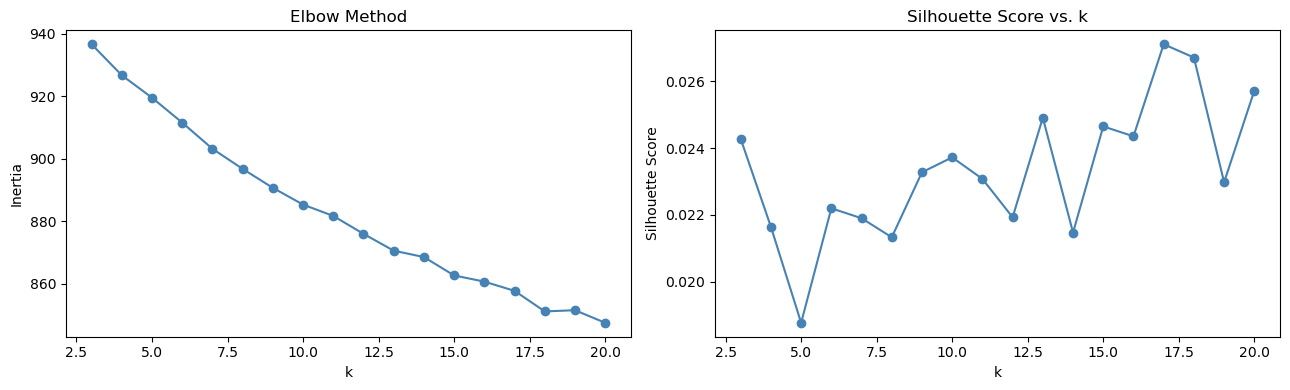

Highest silhouette score: 0.027 at k = 17


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test a range of k values (same approach as Week 8)
K_range = range(3, 21)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(tfidf_matrix)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(tfidf_matrix, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'o-', color='steelblue')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"Highest silhouette score: {max(sil_scores):.3f} at k = {best_k}")

In [17]:
K = 10  # adjust after inspecting the plots above
km_tfidf = KMeans(n_clusters=K, n_init=10, random_state=42)
recipes_df['cluster_tfidf'] = km_tfidf.fit_predict(tfidf_matrix)

print(f"K-means with k = {K}")
print(f"Silhouette score: {silhouette_score(tfidf_matrix, recipes_df['cluster_tfidf']):.3f}")
print(f"\nRecipes per cluster:")
print(recipes_df['cluster_tfidf'].value_counts().sort_index())

K-means with k = 10
Silhouette score: 0.024

Recipes per cluster:
cluster_tfidf
0    110
1    168
2     68
3     31
4    215
5     54
6    135
7    137
8     49
9     88
Name: count, dtype: int64


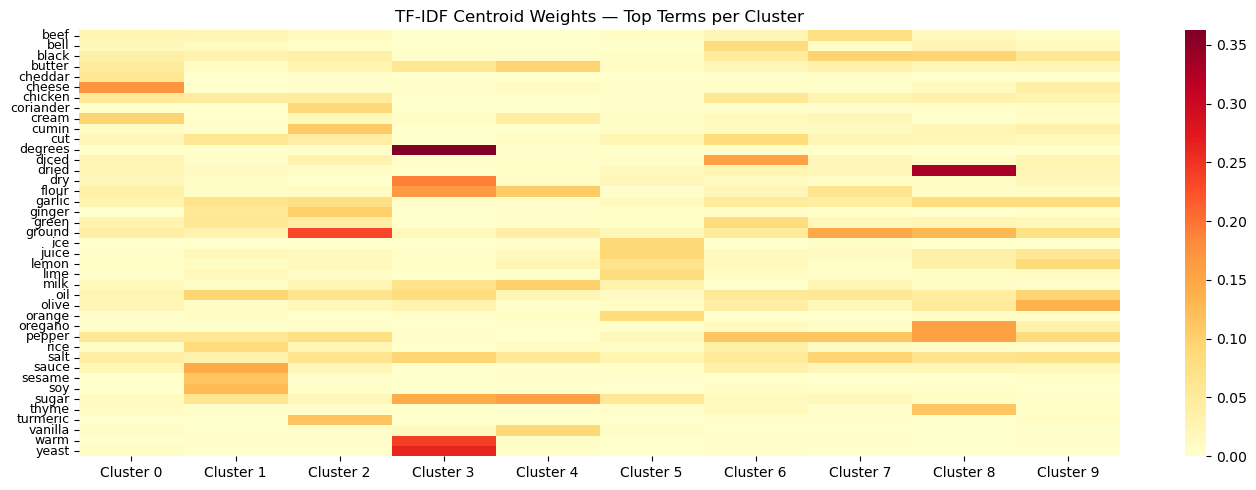

Top terms per cluster:


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9
#1,cheese,sauce,ground,degrees,sugar,juice,diced,ground,dried,olive
#2,cream,soy,turmeric,yeast,flour,ice,pepper,pepper,pepper,oil
#3,cheddar,sesame,cumin,warm,milk,orange,cut,black,oregano,lemon
#4,pepper,oil,ginger,dry,butter,lime,green,salt,ground,pepper
#5,chicken,rice,coriander,flour,vanilla,lemon,bell,beef,thyme,garlic


In [18]:
# Top TF-IDF terms per cluster (based on cluster centroid weights)
n_top = 5
centroids = km_tfidf.cluster_centers_

top_terms_per_cluster = {}
for c in range(K):
    top_idx = centroids[c].argsort()[::-1][:n_top]
    top_terms_per_cluster[f'Cluster {c}'] = [feature_names[i] for i in top_idx]

top_terms_df = pd.DataFrame(top_terms_per_cluster, index=[f'#{i+1}' for i in range(n_top)])

fig, ax = plt.subplots(figsize=(14, 5))
# Heatmap of centroid weights for top terms (union of all top terms)
all_top_idx = set()
for c in range(K):
    all_top_idx.update(centroids[c].argsort()[::-1][:n_top])
all_top_idx = sorted(all_top_idx, key=lambda i: feature_names[i])

heatmap_data = pd.DataFrame(
    centroids[:, all_top_idx].T,
    index=[feature_names[i] for i in all_top_idx],
    columns=[f'Cluster {c}' for c in range(K)]
)
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('TF-IDF Centroid Weights — Top Terms per Cluster')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print("Top terms per cluster:")
top_terms_df

### 2.3 How well do clusters match cuisines?

- Now we reveal the hidden cuisine labels and check alignment.
  
- We'll use the same label-alignment approach as Week 8: for each cluster, find the most common cuisine label and compute the fraction of recipes in that cluster belonging to it.

In [19]:
def cluster_cuisine_alignment(cluster_col, label_col='country'):
    """Compute purity: for each cluster, fraction belonging to the majority cuisine."""
    ct = pd.crosstab(recipes_df[cluster_col], recipes_df[label_col])
    majority_counts = ct.max(axis=1)
    majority_labels = ct.idxmax(axis=1)
    alignment = pd.DataFrame({
        'size': ct.sum(axis=1),
        'majority_cuisine': majority_labels,
        'majority_count': majority_counts,
        'purity': (majority_counts / ct.sum(axis=1)).round(3)
    })
    overall_purity = majority_counts.sum() / ct.sum().sum()
    return alignment, overall_purity

alignment_tfidf, purity_tfidf = cluster_cuisine_alignment('cluster_tfidf')
print(f"Overall purity (TF-IDF): {purity_tfidf:.3f}\n")
alignment_tfidf

Overall purity (TF-IDF): 0.229



,size,majority_cuisine,majority_count,purity
cluster_tfidf,,,,
0,110,Tex-Mex,31,0.282
1,168,Chinese,57,0.339
2,68,Indian,43,0.632
3,31,Jewish,8,0.258
4,215,Jewish,20,0.093
5,54,Spanish,9,0.167
6,135,Cajun and Creole,22,0.163
7,137,Jewish,13,0.095
8,49,Cajun and Creole,14,0.286


### 🧑‍💻 STUDENT TASK

Try a different value of k (e.g., 5 or 15). Which cuisines get split across multiple clusters? Which cuisines get merged into the same cluster? Write 2–3 sentences interpreting what you find.

In [20]:
# 🧑‍💻 STUDENT TASK
# Try a different k and compare. Example:
# K_new = 5
# km_new = KMeans(n_clusters=K_new, n_init=10, random_state=42)
# recipes_df['cluster_new'] = km_new.fit_predict(tfidf_matrix)
# alignment_new, purity_new = cluster_cuisine_alignment('cluster_new')
# print(f"Overall purity (k={K_new}): {purity_new:.3f}")
# alignment_new

In [21]:
# --- MODEL ANSWER ---
for K_new in [5, 15]:
    km_new = KMeans(n_clusters=K_new, n_init=10, random_state=42)
    recipes_df['cluster_new'] = km_new.fit_predict(tfidf_matrix)
    alignment_new, purity_new = cluster_cuisine_alignment('cluster_new')
    print(f"k = {K_new}:  overall purity = {purity_new:.3f}")
    print(alignment_new[['size', 'majority_cuisine', 'purity']].to_string())
    print()

k = 5:  overall purity = 0.177
             size majority_cuisine  purity
cluster_new                               
0             173          Chinese   0.341
1             228           Indian   0.175
2             369          Italian   0.138
3             170           Jewish   0.129
4             115           Jewish   0.130

k = 15:  overall purity = 0.270
             size              majority_cuisine  purity
cluster_new                                            
0              43                      Austrian   0.163
1             110                       Tex-Mex   0.291
2              97              Cajun and Creole   0.175
3             144                        Jewish   0.132
4              71                        Korean   0.592
5              39              Cajun and Creole   0.359
6             106                       Chinese   0.340
7              64                        Indian   0.656
8              37                     Brazilian   0.189
9              25  

### Model Answer — Varying k

<details>
<summary>Click to reveal</summary>

**With a small k (e.g., k = 5):** clusters are large and lump together multiple cuisines. For example, most East-Asian cuisines (Japanese, Chinese, Korean, Vietnamese) may end up in a single cluster because they share ingredients like soy sauce, rice, and ginger. Similarly, several European cuisines may merge. Purity drops because each cluster covers many cuisines.

**With a large k (e.g., k = 15):** clusters are smaller and more specialised. Cuisines with distinctive ingredient signatures (Japanese, Indian) get their own cluster, but less distinctive cuisines (Canadian, German) may get split across multiple clusters. Purity per cluster tends to rise, but many clusters may correspond to the same cuisine.

**Key takeaway:** there is a trade-off. Small k under-segments (merges different cuisines), large k over-segments (splits the same cuisine). Neither perfectly recovers the 49 true cuisines — partly because some cuisines genuinely overlap in their ingredient profiles.

</details>

---
## 3 · Word Embeddings (GloVe)

### 3.1 What is an embedding?

- An **embedding** represents an object — a word, a product, a song — as a short list 
of numbers, so that *similar objects get similar numbers*.

- For example, the words "cat" and "kitten" would end up with nearly identical vectors, 
while "cat" and "democracy" would be far apart.

- This is different from TF-IDF, which gave each document a very long, mostly-empty 
vector (one slot per vocabulary word). An embedding is **dense and compact** — every 
number carries meaning, and the vectors are much shorter (~50–300 numbers instead of 
thousands).

### 3.2 Pre-trained embeddings

**Pre-trained** means the embedding vectors were learned *in advance* on a very large text corpus (collection of text documents such as recipes) — not on our recipe data. Someone else did the expensive training; we just download the result and use it. This is analogous to using a pre-built map: you didn't survey the terrain yourself, but you still benefit from the geography it encodes.

**How are word embeddings learned?** The core idea is the *distributional hypothesis*: words that appear in similar contexts tend to have similar meanings. An algorithm reads billions of words of text (news articles, Wikipedia, web pages) and adjusts each word's vector so that words sharing similar neighbours end up close together. The individual dimensions don't have simple labels like "spiciness" or "sweetness" — they're abstract features that emerge from patterns in the training data.

### 3.3 GloVe

**GloVe** (Global Vectors for Word Representation) is one such algorithm. It was trained by Stanford researchers on 6 billion words of text. We'll use the **GloVe-50** variant, which represents each word as a vector of **50 numbers**. After training:

- "cumin" and "coriander" are close (both are spices that co-occur with similar words)
- "cumin" and "chocolate" are far apart
- "butter" and "margarine" are close

This is something TF-IDF cannot capture — in TF-IDF, every term is equally unrelated to every other term.

### 3.4 Loading GloVe vectors

⚠️ **Important:** Run the `%pip install gensim` cell below **once**, then **restart the kernel** before continuing. After restarting, you can skip the pip cell and run from the import cell onward.

In [22]:
#%pip install gensim

In [23]:
import logging
import gensim.downloader as api
logging.getLogger('gensim').setLevel(logging.WARNING)
glove = api.load('glove-wiki-gigaword-50')

In [24]:
print(glove.most_similar('cumin'))

[('coriander', 0.9457870721817017), ('teaspoon', 0.8907185196876526), ('turmeric', 0.8896726369857788), ('teaspoons', 0.8871698379516602), ('tablespoon', 0.8628989458084106), ('paprika', 0.8265283107757568), ('oregano', 0.8216561079025269), ('garlic', 0.8215745091438293), ('mustard', 0.8142250776290894), ('tablespoons', 0.8080428242683411)]


### 3.5 Filtering to our vocabulary

- The full GloVe model contains vectors for 400,000 words — far more than we need. To stay well within our **2 GB memory budget** on the UofT Jupyterhub, we'll extract only the vectors for words that actually appear in our ingredient lists. 

- This is a practical data-science habit: load only what you need.

In [25]:
# Tokenise ingredients into individual words, removing stop words.
# We reuse recipe_stop_words (English + measurement terms) from Section 1.
# from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
# recipe_stop_words = list(ENGLISH_STOP_WORDS.union(stop_words))

# This is important: unlike TF-IDF, averaging GloVe vectors has no built-in
# down-weighting, so stop words would pull every recipe toward the same point.

import re

def tokenise_ingredients(text):
    """Split ingredient text into lowercase alpha-only words, removing stop words."""
    words = re.findall(r'[a-z]+', text.lower())
    return [w for w in words if w not in recipe_stop_words and len(w) > 2]

# Build vocabulary from our corpus
all_ingredient_words = set()
for text in recipes_df['ingredients']:
    all_ingredient_words.update(tokenise_ingredients(text))

# Filter: keep only words that appear in GloVe
in_glove = {w for w in all_ingredient_words if w in glove}
not_in_glove = all_ingredient_words - in_glove

print(f"Unique words in ingredients: {len(all_ingredient_words):,}")
print(f"  Found in GloVe:  {len(in_glove):,} ({len(in_glove)/len(all_ingredient_words)*100:.0f}%)")
print(f"  Not in GloVe:    {len(not_in_glove):,}")
print(f"\nSample missing words: {sorted(not_in_glove)[:15]}")

Unique words in ingredients: 1,456
  Found in GloVe:  1,391 (96%)
  Not in GloVe:    65

Sample missing words: ['acini', 'annato', 'barbequed', 'besan', 'breader', 'cantanzaro', 'cavatappi', 'chunjang', 'ciliegine', 'conchiglie', 'culantro', 'debearded', 'diakon', 'ditalini', 'divied']


In [26]:
# Nearest neighbours for a few interesting ingredient words
for word in ['cumin', 'soy', 'mozzarella', 'cilantro', 'butter', 'rice']:
    if word in glove:
        neighbours = glove.most_similar(word, topn=5)
        neighbour_str = ', '.join(f'{w} ({s:.2f})' for w, s in neighbours)
        print(f"{word:12s} → {neighbour_str}")
    else:
        print(f"{word:12s} → (not in GloVe)")

cumin        → coriander (0.95), teaspoon (0.89), turmeric (0.89), teaspoons (0.89), tablespoon (0.86)
soy          → soya (0.77), beans (0.76), fermented (0.76), juice (0.76), sauce (0.76)
mozzarella   → cheese (0.83), pimento (0.81), feta (0.79), parmesan (0.77), ricotta (0.77)
cilantro     → garnish (0.88), chives (0.88), parsley (0.88), chopped (0.85), garlic (0.84)
butter       → mixture (0.85), flour (0.84), cream (0.84), cheese (0.84), bread (0.84)
rice         → wheat (0.78), corn (0.74), vegetables (0.73), grain (0.71), beans (0.70)


### 3.6 Recipe-level embeddings

Each recipe is a list of ingredient words. To get a single vector per recipe, we take the **mean** of the GloVe vectors for all words in that recipe's ingredient list (skipping any words not in GloVe). This gives us a dense (n_recipes × 50) matrix.

In [27]:
def recipe_glove_embedding(text):
    """Mean GloVe vector for a recipe's ingredient words."""
    tokens = tokenise_ingredients(text)
    vecs = [glove[w] for w in tokens if w in glove]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(glove.vector_size)

glove_matrix = np.vstack(recipes_df['ingredients'].apply(recipe_glove_embedding).values)
print(f"GloVe recipe matrix: {glove_matrix.shape}  (n_recipes × embedding_dim)")

GloVe recipe matrix: (1055, 50)  (n_recipes × embedding_dim)


### 3.7 K-Means on GloVe embeddings

In [28]:
km_glove = KMeans(n_clusters=K, n_init=10, random_state=42)
recipes_df['cluster_glove'] = km_glove.fit_predict(glove_matrix)

alignment_glove, purity_glove = cluster_cuisine_alignment('cluster_glove')

print(f"K-means (k={K}) on GloVe embeddings")
print(f"Silhouette score: {silhouette_score(glove_matrix, recipes_df['cluster_glove']):.3f}")
print(f"Overall purity:   {purity_glove:.3f}  (TF-IDF was {purity_tfidf:.3f})\n")
alignment_glove

K-means (k=10) on GloVe embeddings
Silhouette score: 0.071
Overall purity:   0.172  (TF-IDF was 0.229)



,size,majority_cuisine,majority_count,purity
cluster_glove,,,,
0,114,Jewish,17,0.149
1,87,Italian,15,0.172
2,180,Spanish,20,0.111
3,64,Australian and New Zealander,8,0.125
4,97,Australian and New Zealander,9,0.093
5,120,Chinese,41,0.342
6,139,Indian,33,0.237
7,64,Spanish,8,0.125
8,63,Jewish,14,0.222


### 🧑‍💻 STUDENT TASK

Find two ingredients whose nearest GloVe neighbours are **surprising or wrong**. Explain what might cause this — remember that GloVe was trained on Wikipedia/news text, not recipe data.

In [29]:
# 🧑‍💻 STUDENT TASK
# Explore glove.most_similar() for various ingredient words.
# Find two whose nearest neighbours are surprising or wrong.
# Example:
# print(glove.most_similar('wasabi', topn=10))
# print(glove.most_similar('tablespoon', topn=10))

### Model Answer — Surprising GloVe neighbours

<details>
<summary>Click to reveal</summary>

**Example 1: "tablespoon"**
```
glove.most_similar('tablespoon') → teaspoon, cup, chopped, tablespoons, ...
```
This makes sense in a cooking context, but GloVe learned this from *general text* — "tablespoon" and "teaspoon" co-occur in news articles about recipes, health tips, etc. It's not really capturing *ingredient meaning*, just co-occurrence with measurement words.

**Example 2: "wasabi"**
```
glove.most_similar('wasabi') → sushi, sashimi, tempura, ...
```
GloVe associates "wasabi" with Japanese restaurant terms because that's the context in which it appears in news and Wikipedia. But in a recipe context, wasabi is a *condiment* — its nearest culinary neighbours should be other spicy condiments like horseradish or mustard.

**Why this happens:** GloVe was trained on Wikipedia and news text, not recipe data. It captures *general language co-occurrence* — words that appear near each other in news articles. This often aligns with culinary meaning (cumin ≈ coriander), but sometimes doesn't (wasabi ≈ sushi is a cultural association, not an ingredient similarity). A domain-specific embedding trained on recipe text would give different (and possibly better) neighbours for these words.

</details>

In [30]:
# --- MODEL ANSWER ---
for word in ['tablespoon', 'wasabi', 'cream', 'pepper']:
    if word in glove:
        neighbours = glove.most_similar(word, topn=5)
        neighbour_str = ', '.join(f'{w} ({s:.2f})' for w, s in neighbours)
        print(f"{word:12s} → {neighbour_str}")
    else:
        print(f"{word:12s} → (not in GloVe)")

tablespoon   → tablespoons (0.95), teaspoons (0.93), teaspoon (0.93), vinegar (0.87), cumin (0.86)
wasabi       → horseradish (0.79), miso (0.79), mayonnaise (0.75), chilli (0.73), aioli (0.73)
cream        → chocolate (0.89), butter (0.84), caramel (0.82), vanilla (0.82), soda (0.82)
pepper       → ginger (0.89), garlic (0.86), mustard (0.83), vinegar (0.82), chopped (0.81)


---
## 4 · Bottleneck Encoder (Autoencoder)

### 4.1 Motivation: learning a representation tuned to our data

- TF-IDF gave us a sparse representation (~1,550 numbers per recipe, mostly zeros) and GloVe gave us a pre-trained dense one (50 numbers per recipe).

- Can we do better by *learning* a compressed representation "end-to-end", specifically tuned to our recipe data?

### 4.2 What is an autoencoder?

- An **autoencoder** is a neural network trained to reconstruct its own input. It is an 
example of **self-supervised learning** — no labels needed, because the input itself 
acts as the training target. This means we can train on our entire recipe dataset for free.

- The trick is that the network is forced through a narrow **bottleneck** layer in the 
middle — so it must learn a compact encoding that captures the most important structure 
in the data.

```
Input (TF-IDF vector, ~1550 numbers per recipe)
       ↓
  [Encoder: Dense layer]
       ↓
  Bottleneck (16 numbers per recipe)  ← this is our learned embedding
       ↓
  [Decoder: Dense layer]
       ↓
Output (reconstructed TF-IDF vector, ~1550 numbers per recipe)
```

After training, we throw away the decoder and use the bottleneck activations as our 
new representation. The result: **each recipe is mapped to just 16 numbers** — a 
massive compression from the original ~1,550. If the autoencoder does its job well, 
those 16 numbers preserve the information that matters most for distinguishing recipes.

### 4.3 A brief orientation to Keras

This is your first time using **Keras**, a high-level API for building neural networks (backed by TensorFlow). The pattern is:

1. **Build** — define layers and connect them
2. **Compile** — choose an optimizer and loss function
3. **Fit** — train the model on data

We'll keep the model very small (one hidden layer) to respect our 2 GB memory constraint.

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Convert sparse TF-IDF matrix to dense (small enough for 2 GB)
X_tfidf = tfidf_matrix.toarray().astype('float32')
n_features = X_tfidf.shape[1]  # ~1,550 (one dimension per vocabulary word)

# --- INPUT ---
# Each recipe is a TF-IDF vector of ~1,550 numbers
input_layer = keras.Input(shape=(n_features,))

# --- BOTTLENECK ---
# Compress down to 16 numbers — this is the learned embedding we care about
encoded = layers.Dense(16, activation='relu', name='bottleneck')(input_layer)

# --- OUTPUT ---
# Reconstruct the original ~1,550 numbers from the 16-number bottleneck
# sigmoid used because TF-IDF values are normalised between 0 and 1
decoded = layers.Dense(n_features, activation='sigmoid')(encoded)

# Combine into a single model: input → bottleneck → output
autoencoder = keras.Model(input_layer, decoded)

# MSE loss: penalise the difference between the original and reconstructed vector
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │        23,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1472)           │        25,024 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,592 (189.81 KB)

 Trainable params: 48,592 (189.81 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Extract the encoder (input → bottleneck) to get 16-dim embeddings
encoder = keras.Model(autoencoder.input, autoencoder.get_layer('bottleneck').output)
ae_matrix = encoder.predict(X_tfidf, verbose=0)

print(f"Autoencoder recipe matrix: {ae_matrix.shape}")
print(f"Each recipe is now represented by just {ae_matrix.shape[1]} numbers.")

Autoencoder recipe matrix: (1055, 16)
Each recipe is now represented by just 16 numbers.


### 4.4 K-Means on autoencoder embeddings

In [33]:
km_ae = KMeans(n_clusters=K, n_init=10, random_state=42)
recipes_df['cluster_ae'] = km_ae.fit_predict(ae_matrix)

alignment_ae, purity_ae = cluster_cuisine_alignment('cluster_ae')

print(f"K-means (k={K}) on autoencoder embeddings (16-dim)")
print(f"Silhouette score: {silhouette_score(ae_matrix, recipes_df['cluster_ae']):.3f}")
print(f"Overall purity:   {purity_ae:.3f}  (TF-IDF: {purity_tfidf:.3f}, GloVe: {purity_glove:.3f})\n")
alignment_ae

K-means (k=10) on autoencoder embeddings (16-dim)
Silhouette score: 0.076
Overall purity:   0.120  (TF-IDF: 0.229, GloVe: 0.172)



,size,majority_cuisine,majority_count,purity
cluster_ae,,,,
0,115,Tex-Mex,11,0.096
1,99,Indian,8,0.081
2,171,Korean,19,0.111
3,81,Cajun and Creole,12,0.148
4,65,Jewish,6,0.092
5,131,Indian,22,0.168
6,109,Jewish,15,0.138
7,96,French,9,0.094
8,84,Cajun and Creole,9,0.107


### 4.5 Comparing representations

We've now built three different representations of the same recipes. How do we decide which one is "best"? There is no single answer — it depends on what you care about. Here are three lenses:

| Criterion | What it measures | How we assess it |
|---|---|---|
| **Cluster purity** | Do clusters align with true cuisine labels? | Higher overall purity = better separation of cuisines |
| **Silhouette score** | Are clusters internally tight and well-separated? | Higher = more distinct clusters (no labels needed) |
| **Reconstruction loss** | How much information did compression discard? | Lower MSE = less information lost (autoencoders only) |

No single metric tells the whole story. A representation might have high silhouette score but low purity (tight clusters that don't correspond to cuisines). Or high purity but only because k is large. Comparing across multiple criteria gives a more honest picture.

Let's put all three representations side by side.

In [34]:
# Summary comparison table
comparison = pd.DataFrame({
    'Representation': ['TF-IDF', 'GloVe', 'Autoencoder'],
    'Dimensions': [tfidf_matrix.shape[1], glove_matrix.shape[1], ae_matrix.shape[1]],
    'Type': ['Sparse', 'Dense (pre-trained)', 'Dense (learned)'],
    'Silhouette': [
        silhouette_score(tfidf_matrix, recipes_df['cluster_tfidf']),
        silhouette_score(glove_matrix, recipes_df['cluster_glove']),
        silhouette_score(ae_matrix, recipes_df['cluster_ae'])
    ],
    'Cluster Purity': [purity_tfidf, purity_glove, purity_ae]
}).set_index('Representation')

comparison['Silhouette'] = comparison['Silhouette'].round(3)
comparison['Cluster Purity'] = comparison['Cluster Purity'].round(3)

print(f"All methods use k = {K} clusters.\n")
comparison

All methods use k = 10 clusters.



,Dimensions,Type,Silhouette,Cluster Purity
Representation,,,,
TF-IDF,1472,Sparse,0.024,0.229
GloVe,50,Dense (pre-trained),0.071,0.172
Autoencoder,16,Dense (learned),0.076,0.120


### 4.6 Interpreting the comparison

**What the numbers show:**

- **Silhouette score** measures cluster quality *without labels*. TF-IDF often wins here because its high dimensionality gives k-means more room to find separable clusters.
- **Cluster purity** measures alignment *with labels*. This is the more task-relevant metric — it answers "did the clusters recover actual cuisines?" TF-IDF typically leads here too, because its sparse, interpretable features directly encode which ingredients appear.

**So which is "best"?**

For this specific task — recovering cuisine identity from ingredient text — **TF-IDF is hard to beat**. It's simple, fast, interpretable, and retains the full ingredient signal. GloVe's semantic knowledge (cumin ≈ coriander) sounds appealing but the averaging step and domain mismatch (Wikipedia ≠ recipes) hurt more than they help. The autoencoder learns a compact, data-specific representation, but compressing ~1,550 dims to 16 inevitably discards some cuisine-discriminating detail.

That said, "best" depends on context:
- If you need **interpretability** (which terms drive each cluster?) → TF-IDF
- If you need a **low-dimensional input** for a downstream model → autoencoder
- If you are working with **free-form text** (not ingredient lists) where word meaning matters more → pre-trained embeddings like GloVe or BERT

**What the numbers show:**

- **Silhouette score** measures cluster quality *without labels*. TF-IDF often wins here because its high dimensionality gives k-means more room to find separable clusters.
- **Cluster purity** measures alignment *with labels*. This is the more task-relevant metric — it answers "did the clusters recover actual cuisines?" TF-IDF typically leads here too, because its sparse, interpretable features directly encode which ingredients appear.

**So which is "best"?**

For this specific task — recovering cuisine identity from ingredient text — **TF-IDF is hard to beat**. It's simple, fast, interpretable, and retains the full ingredient signal. GloVe's semantic knowledge (cumin ≈ coriander) sounds appealing but the averaging step and domain mismatch (Wikipedia ≠ recipes) hurt more than they help. The autoencoder learns a compact, data-specific representation, but compressing ~1,550 dims to 16 inevitably discards some cuisine-discriminating detail.

That said, "best" depends on context:
- If you need **interpretability** (which terms drive each cluster?) → TF-IDF
- If you need a **low-dimensional input** for a downstream model → autoencoder
- If you are working with **free-form text** (not ingredient lists) where word meaning matters more → pre-trained embeddings like GloVe or BERT

### 4.7 Application: a recipe search engine using TF-IDF

Now that we have three different numeric representations of every recipe, we can build something practical: a **recipe search engine**. Imagine you open the fridge and find soy sauce, rice, ginger, sesame oil, and garlic. Which recipes in our dataset best match those ingredients?

The idea is simple and powerful — it's the same principle behind search engines like Google and recommendation systems like Netflix:

1. **Vectorise the corpus** — we already did this: `tfidf_matrix` contains a TF-IDF vector for every recipe.
2. **Vectorise the query** — transform the user's ingredient list through the *same* `TfidfVectorizer` (so it lives in the same vector space).
3. **Cosine similarity** — compute the similarity between the query vector and every recipe vector.
4. **Rank and return** — the recipes with the highest cosine similarity are the best matches.

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_recipes_tfidf(query_ingredients, top_k=5):
    """Given a free-text ingredient list, return the most similar recipes."""

    # Step 1: transform the query through the SAME vectorizer used on the corpus.
    # This ensures the query lives in the same TF-IDF vector space as the recipes.
    query_vec = vectorizer.transform([query_ingredients])

    # Step 2: compute cosine similarity between the query vector and every
    # recipe vector in tfidf_matrix.  Result is a 1-D array of length n_recipes.
    sims = cosine_similarity(query_vec, tfidf_matrix)[0]

    # Step 3: sort by similarity (highest first) and keep the top k matches.
    best_idx = sims.argsort()[::-1][:top_k]

    # Step 4: collect results into a readable table.
    results = []
    for i in best_idx:
        results.append({
            'recipe': recipes_df.loc[i, 'name'],
            'cuisine': recipes_df.loc[i, 'country'],
            'similarity': round(sims[i], 3)
        })
    return pd.DataFrame(results)

# Example: what can I make with these ingredients?
print("Query: soy sauce, rice, ginger, sesame oil, garlic\n")
find_similar_recipes_tfidf("soy sauce, rice, ginger, sesame oil, garlic")

Query: soy sauce, rice, ginger, sesame oil, garlic



,recipe,cuisine,similarity
0,Spicy Szechuan Green Beans,Chinese,0.563
1,Beef Bulgogi with Dipping Sauce,Korean,0.523
2,3-Ingredient Japanese Potsticker Dip,Japanese,0.521
3,Perfect Pot Stickers,Chinese,0.518
4,Moo Shu Pork,Chinese,0.500


In [38]:
# Try a very different cuisine's ingredients
print("Query: olive oil, tomato, basil, mozzarella, garlic\n")
find_similar_recipes_tfidf("olive oil, tomato, basil, mozzarella, garlic")

Query: olive oil, tomato, basil, mozzarella, garlic



,recipe,cuisine,similarity
0,Pesto Chicken Caprese,Italian,0.495
1,Baked Chicken Marinara,Italian,0.298
2,Shrimp and Okra Gumbo,Cajun and Creole,0.266
3,Baked Rigatoni,Italian,0.250
4,Puttanesca Pasta Bake,Italian,0.244


### Search engines using GloVe and Autoencoder

We can build the same search engine using our other two representations. The logic is identical — only the vectorisation step changes:

| Representation | How the query is vectorised |
|---|---|
| **TF-IDF** | `vectorizer.transform([query])` — same vectorizer used on the corpus |
| **GloVe** | Mean of GloVe vectors for each word in the query — same averaging we used per recipe |
| **Autoencoder** | TF-IDF the query, then pass through the encoder to get 16-dim embedding |

### GloVe Search Engine

In [39]:
def find_similar_recipes_glove(query_ingredients, top_k=5):
    """Search using GloVe embeddings: average word vectors for the query."""

    # Step 1: tokenise the query the same way we tokenised the recipes.
    tokens = tokenise_ingredients(query_ingredients)

    # Step 2: compute the mean GloVe vector (same as recipe_glove_embedding).
    vecs = [glove[w] for w in tokens if w in glove]
    if not vecs:
        print("No query words found in GloVe vocabulary.")
        return pd.DataFrame()
    query_vec = np.mean(vecs, axis=0).reshape(1, -1)

    # Step 3: cosine similarity against every recipe's GloVe vector.
    sims = cosine_similarity(query_vec, glove_matrix)[0]

    # Step 4: rank and return.
    best_idx = sims.argsort()[::-1][:top_k]
    results = []
    for i in best_idx:
        results.append({
            'recipe': recipes_df.loc[i, 'name'],
            'cuisine': recipes_df.loc[i, 'country'],
            'similarity': round(sims[i], 3)
        })
    return pd.DataFrame(results)

### Autoencoder Search Engine

In [40]:
def find_similar_recipes_ae(query_ingredients, top_k=5):
    """Search using autoencoder: TF-IDF the query, then compress to 16-dim."""

    # Step 1: TF-IDF the query using the same vectorizer.
    query_tfidf = vectorizer.transform([query_ingredients]).toarray().astype('float32')

    # Step 2: pass through the encoder to get the 16-dim bottleneck embedding.
    query_vec = encoder.predict(query_tfidf, verbose=0)

    # Step 3: cosine similarity against every recipe's bottleneck embedding.
    sims = cosine_similarity(query_vec, ae_matrix)[0]

    # Step 4: rank and return.
    best_idx = sims.argsort()[::-1][:top_k]
    results = []
    for i in best_idx:
        results.append({
            'recipe': recipes_df.loc[i, 'name'],
            'cuisine': recipes_df.loc[i, 'country'],
            'similarity': round(sims[i], 3)
        })
    return pd.DataFrame(results)

### Compare Search Engine Results

In [43]:
# Compare all three search engines on the same query
query = "soy sauce, rice, ginger, sesame oil, garlic"
print(f"Query: {query}\n")

print("=== TF-IDF ===")
display(find_similar_recipes_tfidf(query, top_k=3))

print("\n=== GloVe ===")
display(find_similar_recipes_glove(query, top_k=3))

print("\n=== Autoencoder ===")
display(find_similar_recipes_ae(query, top_k=3))

Query: soy sauce, rice, ginger, sesame oil, garlic

=== TF-IDF ===


,recipe,cuisine,similarity
0,Spicy Szechuan Green Beans,Chinese,0.563
1,Beef Bulgogi with Dipping Sauce,Korean,0.523
2,3-Ingredient Japanese Potsticker Dip,Japanese,0.521



=== GloVe ===


,recipe,cuisine,similarity
0,3-Ingredient Japanese Potsticker Dip,Japanese,0.976
1,Quick Chinese-Style Vermicelli (Rice Noodles),Chinese,0.975
2,Chinese Broccoli,Chinese,0.973



=== Autoencoder ===


,recipe,cuisine,similarity
0,Ropa Vieja (Cuban Beef),Cuban,0.874
1,Beef Bulgogi,Korean,0.865
2,Baked Sweet And Sour Chicken,Chinese,0.861


### 🧑‍💻 STUDENT TASK

Change the bottleneck dimension (try 4 and 64). What happens to the reconstruction loss and the silhouette score? Write 2–3 sentences explaining the trade-off.

In [44]:
# 🧑‍💻 STUDENT TASK
# Change the bottleneck dimension and compare. Starter code:
#
# for bottleneck_dim in [4, 64]:
#     inp = keras.Input(shape=(n_features,))
#     enc = layers.Dense(bottleneck_dim, activation='relu', name=f'bn_{bottleneck_dim}')(inp)
#     dec = layers.Dense(n_features, activation='sigmoid')(enc)
#     ae = keras.Model(inp, dec)
#     ae.compile(optimizer='adam', loss='mse')
#     h = ae.fit(X_tfidf, X_tfidf, epochs=50, batch_size=64, validation_split=0.2, verbose=0)
#     print(f"Bottleneck = {bottleneck_dim}: final val loss = {h.history['val_loss'][-1]:.5f}")

### Model Answer — Varying bottleneck dimension

<details>
<summary>Click to reveal</summary>

**Bottleneck = 4:**
- Reconstruction loss is **high** — 4 numbers can't capture enough detail to reconstruct ~1,550 TF-IDF weights well.
- Silhouette score drops — too much information was discarded, so cuisines that were distinguishable at 16 dims get merged together.
- The model is *underfitting* — the bottleneck is too narrow to represent the diversity in the data.

**Bottleneck = 64:**
- Reconstruction loss is **lower** than 16 — more capacity means less information is lost.
- Silhouette score may improve slightly or stay similar. With 64 dims, the autoencoder doesn't need to compress as aggressively, so it preserves more fine-grained ingredient differences.
- However, higher-dimensional embeddings are more expensive and may start to overfit on a small dataset like ours (~2,200 recipes).

**The trade-off:** fewer bottleneck dimensions → more compression → more information lost → higher reconstruction loss → worse cluster separation. More bottleneck dimensions → less compression → lower loss → but diminishing returns, higher memory/compute cost, and risk of overfitting. The "sweet spot" depends on the dataset size and how much structure exists in the data.

</details>

In [45]:
# --- MODEL ANSWER ---
for bottleneck_dim in [4, 64]:
    inp = keras.Input(shape=(n_features,))
    enc = layers.Dense(bottleneck_dim, activation='relu', name=f'bn_{bottleneck_dim}')(inp)
    dec = layers.Dense(n_features, activation='sigmoid')(enc)
    ae = keras.Model(inp, dec)
    ae.compile(optimizer='adam', loss='mse')
    h = ae.fit(X_tfidf, X_tfidf, epochs=50, batch_size=64, validation_split=0.2, verbose=0)

    # Extract embeddings and cluster
    enc_model = keras.Model(ae.input, ae.get_layer(f'bn_{bottleneck_dim}').output)
    emb = enc_model.predict(X_tfidf, verbose=0)
    km = KMeans(n_clusters=K, n_init=10, random_state=42)
    labels = km.fit_predict(emb)
    sil = silhouette_score(emb, labels)

    print(f"Bottleneck = {bottleneck_dim}:  val_loss = {h.history['val_loss'][-1]:.5f},  silhouette = {sil:.3f}")

Bottleneck = 4:  val_loss = 0.00301,  silhouette = 0.399
Bottleneck = 64:  val_loss = 0.00086,  silhouette = 0.116


---
## 5 · Synthesis

### What we learned

We tried three ways to turn ingredient text into numbers and then clustered with k-means:

| | TF-IDF | GloVe (pre-trained) | Autoencoder (learned) |
|---|---|---|---|
| **Type** | Sparse | Dense | Dense |
| **Dimensions** | ~1,550 | 50 | 16 |
| **Trained on** | This dataset only | Wikipedia + news (general) | This dataset only |
| **Captures synonyms?** | No — "cumin" ≠ "coriander" | Yes — similar words → similar vectors | Implicitly, through compression |
| **Strengths** | Simple, interpretable, fast | Encodes word meaning; no task-specific training needed | Learns structure specific to this data |
| **Weaknesses** | High-dimensional; ignores word similarity | Pre-trained on non-recipe text; averaging loses word order | Requires choosing architecture; black-box |

Check the comparison table above (Section 4.5) for the actual silhouette and purity numbers.

### Where each is used in practice

- **TF-IDF** remains a strong baseline for document classification, search engines, and information retrieval. It's fast and interpretable.
- **Pre-trained embeddings** (GloVe, Word2Vec, and their modern successors like BERT) are the backbone of modern NLP — used in sentiment analysis, machine translation, chatbots, and more.
- **Autoencoders** are used for dimensionality reduction, anomaly detection, and as building blocks in more complex generative models (e.g., variational autoencoders).

### Closing question

Which of these three representations would you trust most for clustering recipes by cuisine, and why? 

There's no single right answer — it depends on what you value: interpretability, semantic richness, or data-specific tuning.

---
## Lecture Review

### What we covered today

**The problem:** can we recover cuisine identity from ingredient text alone — no nutrition data, no labels?

**Three representations of text:**

| | TF-IDF | GloVe | Autoencoder |
|---|---|---|---|
| **What it produces** | ~1,550 sparse weights per recipe | 50 dense numbers per recipe | 16 dense numbers per recipe |
| **How it works** | Weight each word by distinctiveness (TF × IDF) | Look up pre-trained word vectors, average them | Compress TF-IDF through a neural network bottleneck |
| **Key strength** | Simple, interpretable, retains full signal | Captures word meaning (cumin ≈ coriander) | Learns data-specific structure |
| **Key weakness** | Treats every word as independent | Trained on Wikipedia, not recipes | Black box; requires architecture choices |

**New tools and concepts:**
- **TF-IDF** — term frequency × inverse document frequency; the document-term matrix
- **Cosine similarity** — measures the angle between vectors; preferred over Euclidean distance for sparse text
- **Embeddings** — mapping discrete objects to dense vectors; pre-trained (GloVe) vs. learned (autoencoder)
- **Silhouette score** — label-free measure of cluster quality ($a$ vs. $b$)
- **Autoencoders** — encoder → bottleneck → decoder; build-compile-fit in Keras

**Key takeaway:** the "best" representation depends on your goal. TF-IDF won on clustering purity (it keeps the most information), but embeddings are essential when you need to capture word meaning, reduce dimensionality, or feed into downstream models. All three can power a similarity-based search engine using the same cosine-similarity logic.

**Next week:** test 3